#### 10. Comparação entre os modelos 

Esta etapa tem como objetivo comparar o desempenho dos modelos treinados utilizando:

- conjunto completo de atributos;
- conjunto reduzido contendo apenas atributos extraídos da URL.

A comparação busca avaliar o impacto da redução de complexidade sobre a capacidade preditiva dos modelos, considerando possíveis aplicações em tempo real, como APIs de detecção automática de phishing.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

comparacao = pd.DataFrame({

    'Modelo': [
        'Regressão Logística',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy Completo': [
        0.952,
        0.965,
        0.986
    ],

    'Accuracy URL': [
        0.850,
        0.8695,
        0.900
    ],

    'Recall Completo': [
        0.960,
        0.968,
        0.984
    ],

    'Recall URL': [
        0.878,
        0.895,
        0.918
    ],

    'F1 Completo': [
        0.952,
        0.965,
        0.986
    ],

    'F1 URL': [
        0.854,
        0.8727,
        0.9018
    ],

    'AUC Completo': [
        0.9869,
        0.9650,
        0.9990
    ],

    'AUC URL': [
        0.9143,
        0.8708,
        0.9629
    ]
})

comparacao

,Modelo,Accuracy Completo,Accuracy URL,Recall Completo,Recall URL,F1 Completo,F1 URL,AUC Completo,AUC URL
0,Regressão Logística,0.952,0.8500,0.960,0.878,0.952,0.8540,0.9869,0.9143
1,Decision Tree,0.965,0.8695,0.968,0.895,0.965,0.8727,0.9650,0.8708
2,Random Forest,0.986,0.9000,0.984,0.918,0.986,0.9018,0.9990,0.9629


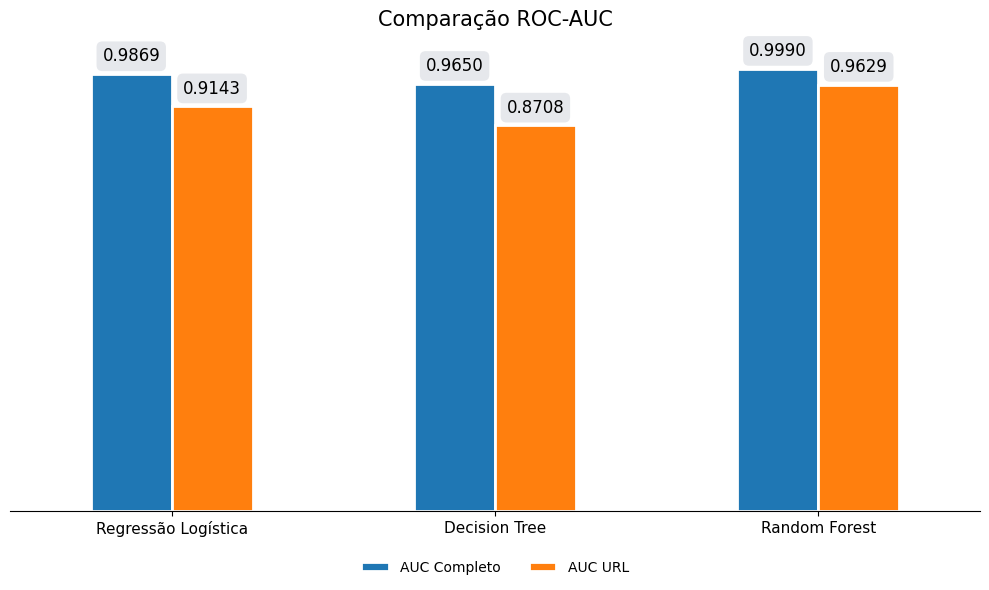

In [18]:
# Comparação de AUC
ax = comparacao.plot(
    x='Modelo',
    y=['AUC Completo', 'AUC URL'],
    kind='bar',
    figsize=(10, 6),

    edgecolor='white',   # borda branca
    linewidth=2
)

# Título
plt.title(
    "Comparação ROC-AUC",
    fontsize=15,
    pad=15
)

# Removendo label eixo X
plt.xlabel("")

# Labels horizontais
plt.xticks(
    rotation=0,
    fontsize=11
)

# Removendo eixo Y
ax.yaxis.set_visible(False)

# Removendo bordas do gráfico
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Valores acima das barras
for container in ax.containers:

    for bar in container:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02,
            f'{height:.4f}',
            ha='center',
            va='bottom',
            fontsize=12,

            bbox=dict(
                boxstyle='round,pad=0.35',
                facecolor='#E5E7EB',
                alpha=0.95,
                edgecolor='none'
            )
        )

# Legenda inferior central
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    frameon=False
)

plt.tight_layout()

plt.show()

In [22]:
comparacao['Perda_AUC_%'] = (
    (
        comparacao['AUC Completo']
        - comparacao['AUC URL']
    )
    /
    comparacao['AUC Completo']
) * 100


In [23]:
comparacao[
    ['Modelo', 'Perda_AUC_%']
]

,Modelo,Perda_AUC_%
0,Regressão Logística,7.356368
1,Decision Tree,9.761658
2,Random Forest,3.613614


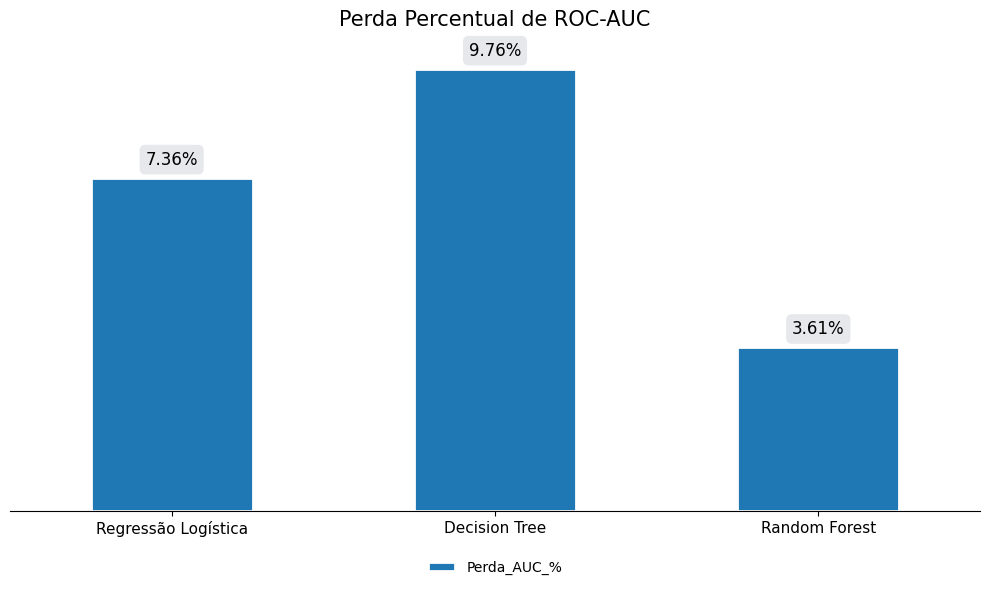

In [27]:
# Gráfico de perda percentual de AUC
ax = comparacao.plot(
    x='Modelo',
    y='Perda_AUC_%',
    kind='bar',
    figsize=(10, 6),

    edgecolor='white',
    linewidth=2,

    legend=True
)

# Título
plt.title(
    "Perda Percentual de ROC-AUC",
    fontsize=15,
    pad=15
)

# Removendo label eixo X
plt.xlabel("")

# Labels horizontais
plt.xticks(
    rotation=0,
    fontsize=11
)

# Removendo eixo Y
ax.yaxis.set_visible(False)

# Removendo bordas
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Valores acima das barras
for container in ax.containers:

    for bar in container:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.2,
            f'{height:.2f}%',

            ha='center',
            va='bottom',
            fontsize=12,

            bbox=dict(
                boxstyle='round,pad=0.35',
                facecolor='#E5E7EB',
                alpha=0.95,
                edgecolor='none'
            )
        )

# Legenda inferior central
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=1,
    frameon=False
)

plt.tight_layout()

plt.show()

A comparação entre os modelos completos e os modelos baseados exclusivamente em URLs demonstrou que a redução de atributos ocasionou impacto relativamente pequeno sobre o desempenho preditivo, especialmente no modelo Random Forest.

O Random Forest apresentou perda de apenas 3.61% na métrica ROC-AUC, indicando que características estruturais da URL concentram grande parte da informação discriminatória necessária para identificação de ataques phishing.

Os resultados reforçam a viabilidade de soluções leves e rápidas baseadas exclusivamente em URLs, especialmente em aplicações em tempo real e APIs de classificação automática.

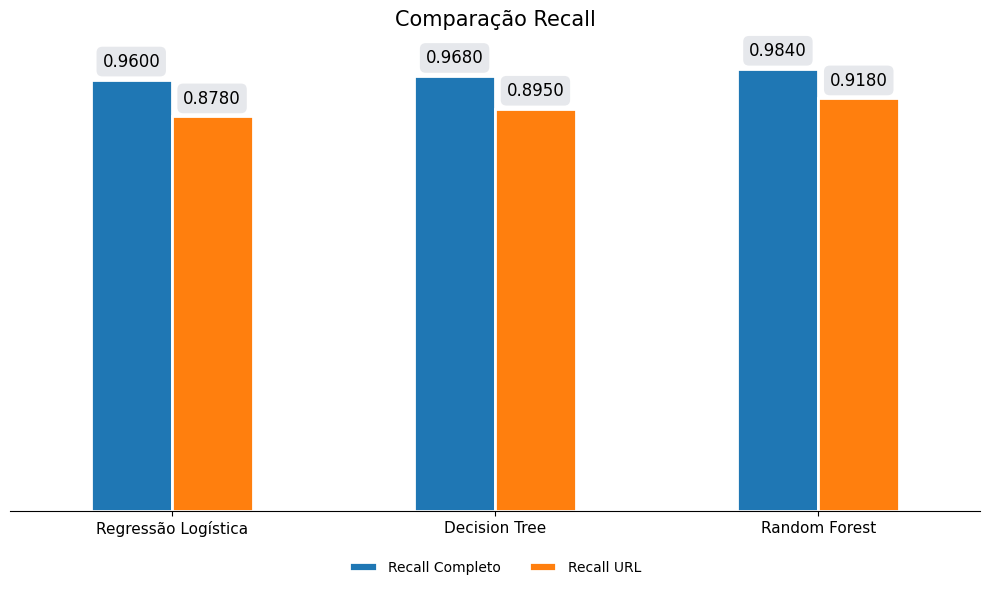

In [21]:
# Comparação de Recall
ax = comparacao.plot(
    x='Modelo',
    y=['Recall Completo', 'Recall URL'],
    kind='bar',
    figsize=(10, 6),

    edgecolor='white',
    linewidth=2
)

# Título
plt.title(
    "Comparação Recall",
    fontsize=15,
    pad=15
)

# Removendo label eixo X
plt.xlabel("")

# Labels horizontais
plt.xticks(
    rotation=0,
    fontsize=11
)

# Removendo eixo Y
ax.yaxis.set_visible(False)

# Removendo bordas do gráfico
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Valores acima das barras
for container in ax.containers:

    for bar in container:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02,
            f'{height:.4f}',
            ha='center',
            va='bottom',
            fontsize=12,

            bbox=dict(
                boxstyle='round,pad=0.35',
                facecolor='#E5E7EB',
                alpha=0.95,
                edgecolor='none'
            )
        )

# Legenda inferior central
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    frameon=False
)

plt.tight_layout()

plt.show()

A análise do Recall demonstrou que os modelos mantiveram elevada capacidade de detecção de URLs maliciosas mesmo utilizando exclusivamente atributos estruturais das URLs.

O modelo Random Forest apresentou Recall de 91.8% no cenário URL-only, indicando que aproximadamente nove em cada dez ataques phishing foram corretamente identificados sem necessidade de análise HTML.

Embora os modelos completos tenham alcançado métricas superiores, a redução observada mostrou-se relativamente pequena diante da significativa simplificação arquitetural obtida.

Os resultados reforçam a viabilidade de soluções leves e rápidas para detecção automática de phishing em aplicações de tempo real.

#### Impacto Computacional

A abordagem baseada exclusivamente em URLs reduz significativamente o custo computacional do sistema, eliminando etapas como:

- carregamento da página HTML;
- parsing do DOM;
- execução de scripts;
- extração de recursos externos.

Essa simplificação torna a solução mais adequada para aplicações em tempo real e APIs de classificação rápida.

Além disso, a utilização exclusiva de atributos da URL reduz riscos associados ao carregamento de páginas maliciosas durante o processo de análise, tornando a solução potencialmente mais segura em ambientes automatizados.

#### Limitações

Algumas limitações do presente trabalho incluem:

- utilização de apenas um dataset;
- ausência de validação em ambientes reais;
- possibilidade de evolução das técnicas de phishing ao longo do tempo;
- dependência das características presentes no conjunto de dados utilizado.